In [1]:
#Python v3.10.11
#Import necessary packages

#general
import os
import sys
import numpy as np
import string
import warnings
warnings.simplefilter(action='ignore')
import pandas as pd

#plotting
import seaborn as sns
import matplotlib.pyplot as plt

#statistics
import scipy
from scipy import stats
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, train_test_split
from greatbrowser import great_analysis

#functions
sys.path.append('functions')
from death_prediction_functions import time_to_death_grouped, cross_validation, train_nn, generate_nn_pred
from gene_analysis_functions import get_cistrome, get_pos

#not in use
from death_prediction_functions import train_ae, test_ae

#visual modifiers
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
'''
Format healthspan data for neural network
'''

os.chdir('C:\\Users\\Sam Anderson\\Desktop\\pellegrini_lab_research\\raw_data')
data = pd.read_excel('healthspan_aging_data.xlsx')
data = data.dropna()

#create 'death clock' column
data['death_wks'] = data['death_mo'].apply(lambda x: x*4.3)
data['age'] = data['time_point_in_study_weeks'].apply(lambda x: x+12)
data['death_clock'] = data['death_wks'] - data['age']

data = data.drop(columns=['animal', 'DAI', 'no_recorded_intervals', 'cohort', 'partner', 'age', 'death_wks', 'death_mo'])

#removes negatives, only one observed in entire dataset anyways though
data = data[data.death_clock != 0]

#split categorical into columns so that a linear relationship is not established
data['strain'] = data['strain'].replace('CD1', '0,1')
data['strain'] = data['strain'].replace('C57BL6', '1,1')
data['strain'] = data['strain'].replace('Sv129', '1,0')

data[['C57BL6J or Sv129Ev', 'CD1 or C57BL6J']] = data['strain'].str.split(',', expand=True)
data[['C57BL6J or Sv129Ev', 'CD1 or C57BL6J']]

data['C57BL6J or Sv129Ev'] =  data['C57BL6J or Sv129Ev'].astype(int)
data['CD1 or C57BL6J'] = data['CD1 or C57BL6J'].astype(int)
data = data.drop(columns=['strain'])

#convert strings to strain indicators
data['rank'] = data['rank'].replace('sub', 0)
data['rank'] = data['rank'].replace('u_d', 1)
data['rank'] = data['rank'].replace('dom', 2)

X = data.drop('death_clock', axis=1)
y = data['death_clock']

X
y

0       69.413333
1       65.413333
2       57.413333
3       49.413333
4       41.413333
          ...    
3395    72.869000
3396    64.869000
3397    48.869000
3398    32.869000
3399    16.869000
Name: death_clock, Length: 3391, dtype: float64

In [3]:
'''
Normalize the data
'''

X = X.rename(columns={'rank': 'Rank'})
X_norm = X.drop(columns=['C57BL6J or Sv129Ev', 'CD1 or C57BL6J', 'Rank'])
X_norm = (X_norm-X_norm.mean())/X_norm.std() #Z-score = (Observed - Expected) / Standard Deviation

X_norm['C57BL6J or Sv129Ev'] = X['C57BL6J or Sv129Ev'] #dummy encoding
X_norm['CD1 or C57BL6J'] = X['CD1 or C57BL6J']
X_norm['Rank'] = X['Rank']
X_norm['time_point_in_study_weeks'] = data['time_point_in_study_weeks']

X = X_norm #since X being the input data name is common practice
X

,aggression_index,FI_kcal,BW_g,FM_g,FFM_g,GLU_mg/dL,time_point_in_study_weeks,C57BL6J or Sv129Ev,CD1 or C57BL6J,Rank
0,1.351078,1.373268,0.370971,0.103955,0.552144,0.571599,0,0,1,2
1,1.351078,0.281961,0.037180,-0.591289,0.698571,-0.328829,4,0,1,2
2,1.351078,2.028052,2.272571,2.200869,1.828153,0.121385,12,0,1,2
3,1.351078,-0.809345,2.717626,2.616524,2.028619,3.030461,20,0,1,2
4,1.351078,1.700660,2.768201,2.543831,2.321473,6.355118,28,0,1,2
...,...,...,...,...,...,...,...,...,...,...
3395,0.689086,-0.154561,-0.276382,-0.212912,-0.146872,0.363808,52,1,1,1
3396,0.689086,-0.481953,0.745222,1.173847,0.088458,-0.294197,60,1,1,1
3397,0.689086,0.500223,0.542924,0.802926,0.029189,-0.051774,76,1,1,1
3398,0.689086,-0.918476,0.826141,1.220445,0.405717,0.779390,92,1,1,1


In [4]:
'''
Determine differences in model accuracy depending on which trait is removed
'''

epochs = 106
batch_size = 32

trait_loss_w = {}
trait_loss_wout = {}
trait_loss_avg = {}

n_iterations = 5 #for cross valu
n_varients = 2 #with and without time

n = 0
working_data = X
status = 'with_time'
while n < n_varients:
   for column in working_data:

      #Drop unused column
      #Want to drop both strain values at once
      if 'C57BL6J or Sv129Ev' in column:
         continue
      elif 'CD1 or C57BL6J' in column:
         working_data = working_data.drop(columns = [column, 'C57BL6J or Sv129Ev'])
         column = 'Strain'
      else:
         working_data = working_data.drop(columns = [column])

      if status == 'with_time': print(f'\nremoved trait: {column}')
      else: print(f'\nremoved traits: {column} and timepoint')

      #run model
      all_approx, all_actual, all_losses = cross_validation(working_data, y, batch_size, epochs, n_iterations)
      
      #calculate average loss by trait
      trait_loss_avg[f'{column}_{status}'] = sum(all_losses) / len(all_losses)

      #get all losses for each trait and add to appropriate dictionary
      if status == 'with_time':
         trait_loss_w[column] = all_losses
      else:
         trait_loss_wout[column] = all_losses
      
   status = 'no_time'
   working_data = X.drop(columns = 'time_point_in_study_weeks')
   n+=1

trait_loss_avg


removed trait: aggression_index


IntProgress(value=0, description='Training', max=5)


removed trait: FI_kcal


IntProgress(value=0, description='Training', max=5)


removed trait: BW_g


...


removed traits: Strain and timepoint


IntProgress(value=0, description='Training', max=5)


removed traits: Rank and timepoint


IntProgress(value=0, description='Training', max=5)

{'aggression_index_with_time': 16.434957442754147,
 'FI_kcal_with_time': 17.37431466323111,
 'BW_g_with_time': 16.606366607823322,
 'FM_g_with_time': 18.37508330141497,
 'FFM_g_with_time': 17.33329347208779,
 'GLU_mg/dL_with_time': 18.160208186906637,
 'time_point_in_study_weeks_with_time': 25.492512324562128,
 'Strain_with_time': 24.8007399990211,
 'Rank_with_time': 24.785303166969534,
 'aggression_index_no_time': 19.339439553891435,
 'FI_kcal_no_time': 19.525626211629877,
 'BW_g_no_time': 19.54695135209276,
 'FM_g_no_time': 19.73674765546122,
 'FFM_g_no_time': 24.18148005630201,
 'GLU_mg/dL_no_time': 25.424026799377533,
 'Strain_no_time': 24.867111504376375,
 'Rank_no_time': 24.85194690462767}

In [5]:
'''
Get saliency maps for full model and timepoint removed model
'''

#These results are commented out because they are frankly pretty useless.. 
#its apparent that using a saliency map here is suboptimal due to the high volume
#of model noise. The fact that timepoint isn't being identified as significant is
#also intuitively illogical

epochs = 106
batch_size = 32

split_size = 5 #for genmap=True this just tells us what percent (100/5 = 20%) to test with

#run model with nothing removed
working_data = X
saliency_map = cross_validation(working_data, y, batch_size, epochs, split_size, gen_map=True)

#run model with timepoint removed
working_data = X.drop(columns = 'time_point_in_study_weeks')
saliency_map_notime = cross_validation(working_data, y, batch_size, epochs, split_size, gen_map=True)

IntProgress(value=0, description='Generating Saliency Map', max=679)

IntProgress(value=0, description='Generating Saliency Map', max=679)

In [6]:
'''
Plot saliency maps
'''

'''

#normalize between 0 and 1
saliency_map_norm = (saliency_map-min(saliency_map))/(max(saliency_map)-min(saliency_map))
saliency_map_notime_norm = (saliency_map_notime-min(saliency_map_notime))/(max(saliency_map_notime)-min(saliency_map_notime))

saliency_maps = pd.DataFrame()
saliency_maps['values_norm'] = list(saliency_map_notime_norm) + list(saliency_map_norm)
saliency_maps['trait'] = list(X.drop(columns = 'time_point_in_study_weeks').columns.tolist() + X.columns.tolist())
saliency_maps['category'] = ['without_time']*len(saliency_map_notime_norm) + ['with_time']*len(saliency_map_norm)

sns.barplot(data = saliency_maps, x = 'trait', y = 'values_norm', hue = 'category', palette='viridis_r')
plt.tick_params(labelrotation=90)

''';

In [7]:
'''
Format strain-trait value correctly
'''

sum_data = pd.DataFrame()
sum_data['trait_avg_loss'] = trait_loss_avg.values()
sum_data['trait_name'] = trait_loss_avg.keys()

sum_data.loc[(sum_data['trait_name'] == 'CD1 or C57BL6J'), 'trait_name'] = 'strain'

#Determine if differences in accuracy are significant

n_datapoints = X.shape[0]//n_iterations+1

loss_notime = 0
loss_time = 0

k = 0
trait_Z = {}

for key in trait_loss_avg.keys():
    non_trait_loss = []
    for key2 in trait_loss_avg.keys():
        if key2 != key: #so if key2 is not the trait being tested
            non_trait_loss.append(trait_loss_avg[key2])
        else:
            trait_sigma = np.std(trait_loss_avg[key]) / np.sqrt(n_datapoints) #std/sqrt(n_samples)
            trait_mean = np.mean(trait_loss_avg[key]) #avg for trait
            
    non_trait_sigma = np.std(non_trait_loss) / np.sqrt(len(non_trait_loss)) #std/sqrt(n_samples)
    non_trait_mean = np.mean(non_trait_loss)

    Z = (trait_mean - non_trait_mean) / np.sqrt(trait_sigma**2 + non_trait_sigma**2) #compare z scores of populations
    trait_Z[key] = Z

dict_as_ordered = []
for trait in sum_data['trait_name']:
    p_values = scipy.stats.norm.sf(abs(trait_Z[trait]))*2
    dict_as_ordered.append(p_values)

sum_data['trait_corr_p_val'] = dict_as_ordered
sum_data

,trait_avg_loss,trait_name,trait_corr_p_val
0,16.434957,aggression_index_with_time,5.694048e-09
1,17.374315,FI_kcal_with_time,6.152079e-06
2,16.606367,BW_g_with_time,2.396126e-08
3,18.375083,FM_g_with_time,1.314568e-03
4,17.333293,FFM_g_with_time,4.732546e-06
5,18.160208,GLU_mg/dL_with_time,4.864879e-04
6,25.492512,time_point_in_study_weeks_with_time,8.973084e-09
7,24.800740,Strain_with_time,1.718824e-06
8,24.785303,Rank_with_time,1.907830e-06
9,19.339440,aggression_index_no_time,4.492646e-02


In [8]:
'''
Use autoencoder to improve quality of data
'''

#This code is not currently in use due to poor performance, likely due to a lack of data

'''
#learn to predict X from X+noise
ae_X = X.drop(columns=['time_point_in_study_weeks', 'C57BL6J or Sv129Ev', 'CD1 or C57BL6J', 'Rank'])
ae_model = train_ae(ae_X, h1=5, out_features=4, batch_size=32, epochs=106)

#apply this to raw X to filter noise
ae_data = test_ae(ae_model, ae_X)

X['aggression_index'] = ae_data.numpy()[0]
X['FI_kcal'] = ae_data.numpy()[1]
X['BW_g'] = ae_data.numpy()[2]
X['FM_g'] = ae_data.numpy()[3]
X['FFM_g'] = ae_data.numpy()[4]
X['GLU_mg/dL'] = ae_data.numpy()[5]

#X[:] = ae_data.numpy().T
X
''';

In [9]:
'''
Cross Validation w/ all traits
'''

epochs = 106
batch_size = 32

n_iterations = 5 #for cross val
n_varients = 2 #with and without time

sum_approx, sum_actual, sum_losses = cross_validation(X, y, batch_size, epochs, n_iterations)

'''
Display cross validation results as a graph using the data from all of the iterations combined
'''

val_predictions = pd.DataFrame()
val_predictions['actual'] = sum_actual
val_predictions['approximation'] = sum_approx

val_predictions = val_predictions.apply(pd.to_numeric)

avg_loss = sum(sum_losses) / len(sum_losses)
corr = stats.kendalltau(x=val_predictions['actual'], y=val_predictions['approximation'])

IntProgress(value=0, description='Training', max=5)

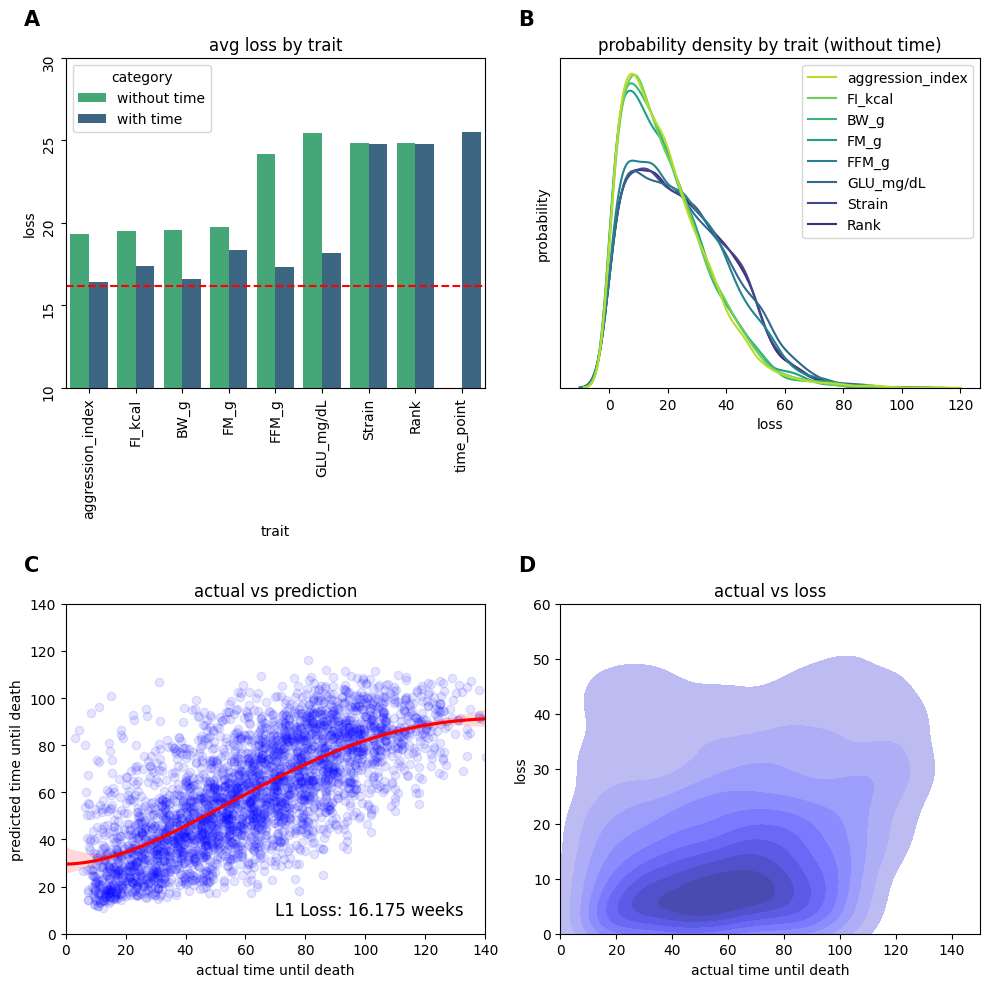

In [10]:
'''
Create plots showing model accuracy
'''

#distinguish subplots
w_time = sum_data[sum_data.apply(lambda r: r.str.contains('with_time', case=False).any(), axis=1)]
wout_time = sum_data[sum_data.apply(lambda r: r.str.contains('no_time', case=False).any(), axis=1)] 

#get rid of un-needed parts of trait names
w_time['trait_name'] = w_time['trait_name'].map(lambda x: x[:-10]) 
wout_time['trait_name'] = wout_time['trait_name'].map(lambda x: x[:-8]) 

#get formatted Loss
loss_clipped = '{0:.3f}'.format(avg_loss)

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 10))
len_traits = [i for i in range(1,9)]

w_time_vals = list(w_time['trait_avg_loss'].values)
w_category = ['with time']*len(w_time_vals) 
w_names = list(w_time['trait_name'].values)

wout_time_vals = list(wout_time['trait_avg_loss'].values)
wout_category = ['without time']*len(wout_time_vals)
wout_names = list(wout_time['trait_name'].values)

both_time = pd.DataFrame()
both_time['loss_values'] = wout_time_vals + w_time_vals
both_time['trait'] = wout_names + w_names
both_time['category'] = wout_category + w_category
both_time = both_time.replace('time_point_in_study_weeks', 'time_point')

#1 - model accuracy by trait removed
sns.barplot(data = both_time, x = 'trait', y = 'loss_values', hue = 'category', palette='viridis_r', ax=axs[0,0])
axs[0,0].axhline(float(loss_clipped), color='red', linestyle='--')
axs[0,0].tick_params(labelrotation=90)
axs[0,0].set_ylabel('loss')
axs[0,0].set_ylim([10, 30])
axs[0,0].set_yticks([10, 15, 20, 25, 30])
axs[0,0].set_title('avg loss by trait', size=12)

#2 - model accuracy with kde

sns.kdeplot(data = trait_loss_wout, hue=None, palette='viridis_r', ax=axs[0,1])
axs[0,1].set_xlabel('loss')
axs[0,1].set_yticks([])
axs[0,1].set_ylabel('probability')
axs[0,1].set_title('probability density by trait (without time)', size=12)

#3 - regplot for prediction vs actual

'''
axs[1,0].plot(np.unique(val_predictions['actual']), np.poly1d(np.polyfit(val_predictions['actual'], 
                val_predictions['approximation'], 1))(np.unique(val_predictions['actual'])), 
                color='orange')
'''

sns.regplot(data=None, x=val_predictions['actual'], y=val_predictions['approximation'], 
                color='red', order=4, ax=axs[1,0], scatter_kws={'alpha':0.1, 'color':'blue'})

sum_actual = [float(x) for x in sum_actual]
sum_approx = [float(x) for x in sum_approx]

x_max = 140

#these need to be the same to avoid unintentionally manipulating the data
axs[1,0].set_xlim([0,x_max])
axs[1,0].set_ylim([0,x_max])

axs[1,0].set_title('actual vs prediction', size=12)
axs[1,0].set_xlabel('actual time until death')
axs[1,0].set_ylabel('predicted time until death')
axs[1,0].text(s=f'L1 Loss: {loss_clipped} weeks', x=(x_max//2), y=8, size=12)
               
#4 - regplot for accuracy vs time to death
accuracy_over_time = [np.mean(i) for i in zip(sum_actual,sum_approx)]

sns.kdeplot(data=None, x=val_predictions['actual'], y=sum_losses, 
                color='blue', order=2, ax=axs[1,1], fill=True)

axs[1,1].set_xlim([0,150])
axs[1,1].set_ylim([0,60])

axs[1,1].set_title('actual vs loss')
axs[1,1].set_xlabel('actual time until death')
axs[1,1].set_ylabel('loss')

axs = axs.flat

for n, ax in enumerate(axs):
    ax.text(-0.1, 1.1, string.ascii_uppercase[n], transform=ax.transAxes, 
            size=15, weight='bold')

plt.tight_layout()

In [11]:
'''
Train the whole model
'''

epochs = 106
batch_size = 32

#Train the model without a validation set
model = train_nn(X, y, batch_size, epochs)

In [12]:
#import the methylation-phenotype cohort
data_2 = pd.read_excel('methylation_phenotype_encoded.xlsx', index_col=0)
data_2 = data_2.dropna()
sep = 55

trait_data = data_2.iloc[:sep]

In [13]:
'''
Import, format, and normalize the phenotype-methylation cohort
'''

group_baseline = ['w12_baseline_food_g', 'w12_baseline_BW', 
                  'w12_baseline_FM_g', 'w12_baseline_FFM_g', 'w12_baseline_GLU']

group_w4 = ['w16_stress_food_g', 'w16_stress_BW', 'w16_stress_FM_g', 
            'w16_stress_FFM_g', 'w16_stress_GLU']

group_M2 = ['M6_poststress_food_g', 'M6_poststress_BW', 
            'M6_poststress_FM_g', 'M6_poststress_FFM_g', 'M6_poststress_GLU']

group_M4 = ['M8_poststress_food_g', 'M8_poststress_BW', 
            'M8_poststress_FM_g', 'M8_poststress_FFM_g', 'M8_poststress_GLU']

group_M6 = ['M10_poststress_food_g', 'M10_poststress_BW', 
            'M10_poststress_FM_g', 'M10_poststress_FFM_g', 'M10_poststress_GLU']

group_M8 = ['M12_poststress_food_g', 'M12_poststress_BW', 
            'M12_poststress_FM_g', 'M12_poststress_FFM_g', 'M12_poststress_GLU']

group_M10 = ['M14_poststress_food_g', 'M14_poststress_BW', 
             'M14_poststress_FM_g', 'M14_poststress_FFM_g', 'M14_poststress_GLU']

group_M12 = ['M16_poststress_food_g', 'M16_poststress_BW', 
             'M16_poststress_FM_g', 'M16_poststress_FFM_g', 'M16_poststress_GLU']

groups = [group_baseline, group_w4, group_M2, group_M4, group_M6, group_M8, group_M10, group_M12]

FI_kcal = []
BW_g = []
FM_g = []
FFM_g = []
GLU_mg = []

for g in groups:
    for f in trait_data.loc[g[0]]:
        FI_kcal.append(round(f*7.716179, 2)) #converts grams to kilocal
    for b in trait_data.loc[g[1]]:
        BW_g.append(b)
    for fm in trait_data.loc[g[2]]:
        FM_g.append(fm)
    for ffm in trait_data.loc[g[3]]:
        FFM_g.append(ffm)
    for glu in trait_data.loc[g[4]]:
        GLU_mg.append(glu)

working_data = pd.DataFrame()

#format data

C57BL6J_or_Sv129Ev = list(trait_data.loc['C57BL6J or Sv129Ev?'])*8
CD1_or_C57BL6J = list(trait_data.loc['CD1 or C57BL6J?'])*8 
aggression_index = list(trait_data.loc['Aggression index'])*8
rank = list(trait_data.loc['Rank'])*8

working_data['C57BL6J or Sv129Ev'] = C57BL6J_or_Sv129Ev
working_data['CD1 or C57BL6J'] = CD1_or_C57BL6J
working_data['Rank'] = rank
working_data['aggression_index'] = aggression_index

working_data['FI_kcal'] = FI_kcal
working_data['BW_g'] = BW_g
working_data['FM_g'] = FM_g
working_data['FFM_g'] = FFM_g
working_data['GLU_mg'] = GLU_mg

working_data = working_data.dropna()
working_data_norm = working_data.drop(columns=['C57BL6J or Sv129Ev', 'CD1 or C57BL6J', 'Rank'])
working_data_norm = (working_data_norm-working_data_norm.mean())/working_data_norm.std() #z score

working_data_norm['C57BL6J or Sv129Ev'] = working_data['C57BL6J or Sv129Ev']
working_data_norm['CD1 or C57BL6J'] = working_data['CD1 or C57BL6J']
working_data_norm['Rank'] = working_data['Rank']

working_data = working_data_norm

#add the time values

rep = 46 #since you add each baseline mouse value, then each w4, etc., this works. 46 is number of mice
group = ['w12'] * rep + ['w16'] * rep + ['M6'] * rep + ['M8'] * rep + ['M10'] * rep + ['M12'] * rep + ['M14'] * rep + ['M16'] * rep
working_data['group'] = group

group_data = working_data.copy()

#replace each timepoint with same format as train dataset, in weeks, with 0 representing the start of the study
working_data['group'] = working_data['group'].replace('w12', 0)
working_data['group'] = working_data['group'].replace('w16', 4)
working_data['group'] = working_data['group'].replace('M6', 8.6)
working_data['group'] = working_data['group'].replace('M8', 17.2)
working_data['group'] = working_data['group'].replace('M10', 25.8)
working_data['group'] = working_data['group'].replace('M12', 34.4)
working_data['group'] = working_data['group'].replace('M14', 43)
working_data['group'] = working_data['group'].replace('M16', 52)

working_data = working_data.rename(columns={'GLU_mg': 'GLU_mg/dL', 'group' : 'time_point_in_study_weeks'})
working_data = working_data[X.columns]
working_data

,aggression_index,FI_kcal,BW_g,FM_g,FFM_g,GLU_mg/dL,time_point_in_study_weeks,C57BL6J or Sv129Ev,CD1 or C57BL6J,Rank
0,1.373209,-0.855727,0.102087,-0.611921,0.839169,-0.831634,0.0,0.0,1.0,2.0
1,1.387117,-1.353742,-0.355454,-1.229810,0.546992,0.562225,0.0,0.0,1.0,2.0
2,1.484477,0.262790,0.231392,-0.226671,0.546992,-1.117554,0.0,0.0,1.0,2.0
3,0.389752,0.138689,0.102087,-0.604477,0.640967,-0.009615,0.0,0.0,1.0,1.0
4,0.065933,-0.979828,-0.106790,-0.889227,0.704187,-0.009615,0.0,0.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...
363,1.414934,-1.601943,0.480056,0.692718,-0.517490,-0.152575,52.0,1.0,1.0,1.0
364,-0.336494,-0.357713,-0.176416,0.476829,-0.197975,0.133345,52.0,1.0,1.0,1.0
365,1.192521,0.262790,0.032461,1.358996,0.297531,0.133345,52.0,1.0,1.0,2.0
366,-0.665823,-0.483426,0.032461,0.769023,-0.309036,1.348505,52.0,1.0,1.0,0.0


In [14]:
'''
Apply the NN model to the phenotype-methylation cohort
'''

#Apply the model to this data
predictions = generate_nn_pred(model, working_data)
working_data['Predicted time until death'] = predictions
group_data['Predicted time until death'] = predictions

working_data.to_excel('death_classifier_pred.xlsx')

In [15]:
'''
prep dataframes for plotting
'''

working_data['strain'] = working_data['CD1 or C57BL6J'] + working_data['C57BL6J or Sv129Ev']*2
working_data['strain'] = working_data['strain'].replace(1, 'CD1')
working_data['strain'] = working_data['strain'].replace(2, 'Sv129Ev')
working_data['strain'] = working_data['strain'].replace(3, 'C57BL6J')

working_data['Rank'] = working_data['Rank'].replace(0, 'sub')
working_data['Rank'] = working_data['Rank'].replace(1, 'u_d')
working_data['Rank'] = working_data['Rank'].replace(2, 'dom')


groups = ['w12', 'w16']
for i in range(6, 17, 2):
  groups.append('M' + str(i))

group_data = time_to_death_grouped(group_data, 'group')
group_data = group_data.reindex(groups)

Average time to death estimate by group:

       Predicted time until death
group                            
w12                     91.313263
w16                     87.599060
M6                      82.954803
M8                      73.372421
M10                     64.987495
M12                     56.549438
M14                     49.606209
M16                     41.936733




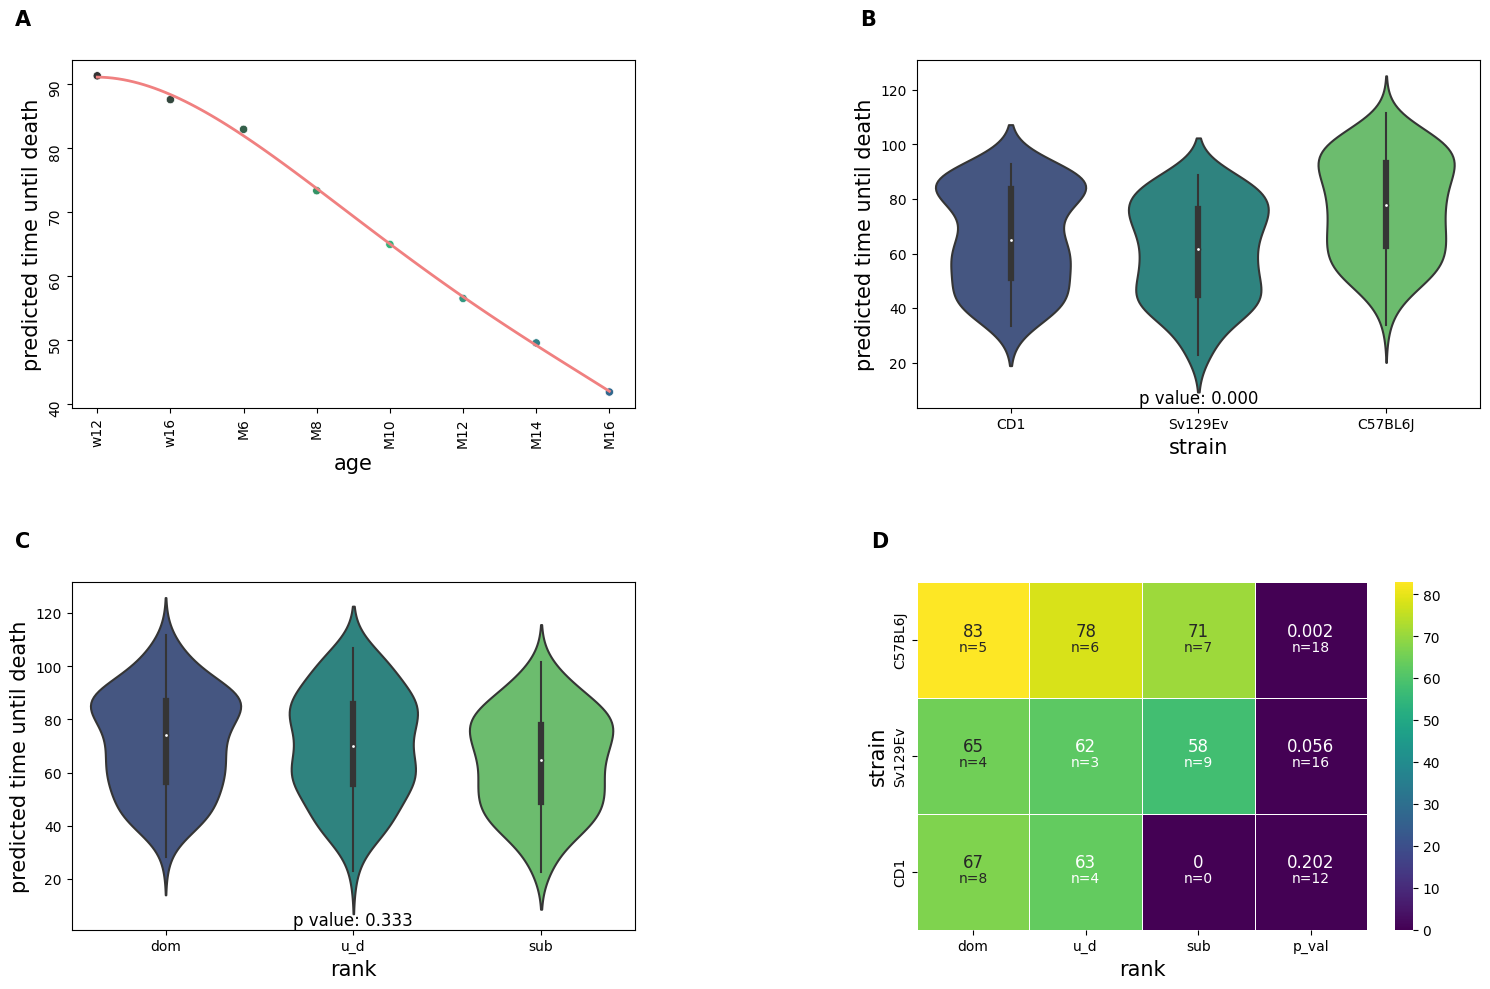

In [16]:
'''
Plot significance of different categories in affecting time to death
'''

##

fig, axs = plt.subplots(2,2, figsize=(15,10))

#plot 1

group_indices = [x for x in range(0, 8)]
sns.regplot(data=None, x=group_indices, y=group_data['Predicted time until death'], ax=axs[0,0],
            scatter=False, line_kws={'color': 'lightcoral', 'lw':2}, order=4, ci=None)

sns.scatterplot(data = None, x = groups, y = group_data['Predicted time until death'], ax=axs[0,0], 
                hue=group_data['Predicted time until death'], palette='viridis_d', legend=False)

axs[0,0].tick_params(labelrotation=90)
axs[0,0].set_xlabel('age', size=15)
axs[0,0].set_ylabel('predicted time until death', size=15)


#plot 2

sns.violinplot(data=None, x=working_data['strain'], y=working_data['Predicted time until death'], 
            ax=axs[0,1], palette='viridis') #note: hue breaks alignment

axs[0,1].set_xlabel('strain', size=15)
axs[0,1].set_ylabel('predicted time until death', size=15)

#get significance and add to plot
strain_corr = stats.kendalltau(x=working_data['strain'], y=working_data['Predicted time until death'])
strain_corr = '{0:.3f}'.format(strain_corr[1])
axs[0,1].set_title(f'p value: {strain_corr}', y=-0.01, size=12)

#plot 3

sns.violinplot(data=None, x=working_data['Rank'], y=working_data['Predicted time until death'], 
            ax=axs[1,0], palette='viridis')

axs[1,0].set_xlabel('rank', size=15)
axs[1,0].set_ylabel('predicted time until death', size=15)

#determine significance of strain and rank respectively, and add these to their respective plots
rank_corr = stats.kendalltau(x=working_data['Rank'], y=working_data['Predicted time until death'])
rank_corr = '{0:.3f}'.format(rank_corr[1])
axs[1,0].set_title(f'p value: {rank_corr}', y=-0.01, size=12)

########################

#plot 4 computations

temp = working_data.copy()

heatmap_data = temp[['strain', 'Rank', 'Predicted time until death']]
heatmap_data = heatmap_data.pivot_table(values='Predicted time until death', index='strain', 
                      columns='Rank', fill_value=0)


heatmap_data = heatmap_data[['dom', 'u_d', 'sub']]
heatmap_data = heatmap_data.reindex(['C57BL6J', 'Sv129Ev', 'CD1'])
#C57, Sv, CD1

##
#determine significance of each heatmap subunit
##

temp['strain'] = temp['strain'].replace('CD1', 1)
temp['strain'] = temp['strain'].replace('Sv129Ev', 2)
temp['strain'] = temp['strain'].replace('C57BL6J', 3)

temp['Rank'] = temp['Rank'].replace('sub', 0)
temp['Rank'] = temp['Rank'].replace('u_d', 1)
temp['Rank'] = temp['Rank'].replace('dom', 2)

# 1 = CD1
# 2 = Sv129
# 3 = C57

#Get significance of rank for each strain

C57 = temp.loc[temp['strain'] == 3]
C57 = C57.drop(columns=['strain'])

C57_rank_corr = stats.kendalltau(x=C57['Rank'], y=C57['Predicted time until death'])
C57_rank_corr = '{0:.3f}'.format(C57_rank_corr[1])

#

Sv129 = temp.loc[temp['strain'] == 2]
Sv129 = Sv129.drop(columns=['strain'])

Sv129_rank_corr = stats.kendalltau(x=Sv129['Rank'], y=Sv129['Predicted time until death'])
Sv129_rank_corr = '{0:.3f}'.format(Sv129_rank_corr[1])

#

CD1 = temp.loc[temp['strain'] == 1]
CD1 = CD1.drop(columns=['strain'])

CD1_rank_corr = stats.kendalltau(x=CD1['Rank'], y=CD1['Predicted time until death'])
CD1_rank_corr = '{0:.3f}'.format(CD1_rank_corr[1])

##

C57_n_dom = int(C57[C57['Rank'] == 2].shape[0]/8)
C57_n_neither = int(C57[C57['Rank'] == 1].shape[0]/8)
C57_n_sub = int(C57[C57['Rank'] == 0].shape[0]/8)

C57_sum = C57_n_dom + C57_n_neither + C57_n_sub

#

Sv129_n_dom = int(Sv129[Sv129['Rank'] == 2].shape[0]/8)
Sv129_n_neither = int(Sv129[Sv129['Rank'] == 1].shape[0]/8)
Sv129_n_sub = int(Sv129[Sv129['Rank'] == 0].shape[0]/8)

Sv129_sum = Sv129_n_dom + Sv129_n_neither + Sv129_n_sub

#

CD1_n_dom = int(CD1[CD1['Rank'] == 2].shape[0]/8)
CD1_n_neither = int(CD1[CD1['Rank'] == 1].shape[0]/8)
CD1_n_sub = 0

CD1_sum = CD1_n_dom + CD1_n_neither + CD1_n_sub

##

n_animals = [[f'n={C57_n_dom}', f'n={C57_n_neither}', f'n={C57_n_sub}', f'n={C57_sum}'],
             [f'n={Sv129_n_dom}', f'n={Sv129_n_neither}', f'n={Sv129_n_sub}', f'n={Sv129_sum}'],
             [f'n={CD1_n_dom}', f'n={CD1_n_neither}', 'n=0', f'n={CD1_sum}']]

#C57, Sv, CD1

pvals_rank_strain = [C57_rank_corr, Sv129_rank_corr, CD1_rank_corr]
heatmap_data['p_val'] = pvals_rank_strain
heatmap_data = heatmap_data.astype(float)

heatmap_pretty = heatmap_data

heatmap_pretty['dom'] = heatmap_pretty['dom'].astype(int)
heatmap_pretty['u_d'] = heatmap_pretty['u_d'].astype(int)
heatmap_pretty['sub'] = heatmap_pretty['sub'].astype(int)

heatmap_pretty = heatmap_pretty.astype(str)
heatmap_pretty = heatmap_pretty.values

#plot 4a

#number of animals
sns.heatmap(data=heatmap_data, annot=n_animals, 
            annot_kws={'va':'top', 'fontsize': 10}, 
            fmt='', cbar=False, ax=axs[1,1])

#plot 4b

#avg time to death
sns.heatmap(data=heatmap_data, annot=heatmap_pretty, 
            annot_kws={'va':'bottom', 'fontsize': 12}, 
            fmt='', cbar=False, ax=axs[1,1])

#plot 4c

#formatting
sns.heatmap(data=heatmap_data, annot=False, linewidth=.5, 
            cmap='viridis', ax=axs[1,1])

axs[1,1].set_xlabel('rank', size=15)
axs[1,1].set_ylabel('strain', size=15)


#Overall figure stuff

plt.rc('axes', titlesize=15)     # fontsize of the axes title
plt.rc('axes', labelsize=12)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=10)    # fontsize of the tick labels
plt.rc('ytick', labelsize=10)    # fontsize of the tick labels

axs = axs.flat

for n, ax in enumerate(axs):
    ax.text(-0.1, 1.1, string.ascii_uppercase[n], transform=ax.transAxes, 
            size=15, weight='bold')

plt.tight_layout()
plt.subplots_adjust(wspace=0.5, hspace=0.5)

In [17]:
'''
calculate a weighted average for each animal using the outputted time until death predictions
'''

n = 0
weights = [2, 5, 8, 11, 14, 17, 20, 23] #since later weights are closer in timepoint to methylation
y = []

while n < rep:
  m = 0
  weight_avg = []
  while m < len(weights): 
    weight_avg.append(predictions[(rep*m)+n][0])
    m+=1
  y.append(np.average(weight_avg, weights=weights))
  n+=1

In [18]:
'''
Decrease number of probes using elastic net model + verify elastic net model's accuracy
'''

#approximate run time on M1 Mac: 80 minutes

meth_data = data_2[sep:]

#split data: shuffles every time any of these are used
test_size = 8
X_train, X_test, y_train, y_test = train_test_split(meth_data.T, y, test_size=(test_size/46))

#identify hyperparameters to optimize, and train these
param_grid = {'alpha' : np.arange(0, 1, 0.1), 'l1_ratio' : np.arange(0, 1, 0.1)}

#perform cross validation to optimize hyperparameters, then test this
elastic_optimized = GridSearchCV(ElasticNet(), param_grid, cv=6, scoring='neg_mean_squared_error') #6 iterations of 7 animals
elastic_optimized.fit(X_train, y_train)

y_pred = elastic_optimized.predict(X_test)

mean_absolute_error(y_test, y_pred)
print(f'mean absolute error: {mean_absolute_error(y_test, y_pred)}')

#retrain model on all inputs
elastic_optimized.fit(meth_data.T, y)

#select probes maintained by the model, and add them to the appropriate format
output = meth_data.copy()
output['coef'] = elastic_optimized.best_estimator_.coef_
output = output[output.coef != 0]
output

mean absolute error: 4.557129764568921


,627,629,630,633,636,637,640,641,643,646,...,736,741,742_1,744,753,754,757,758,764,coef
ID,,,,,,,,,,,,,,,,,,,,,
cg06905417_TC11,0.648283,0.735703,0.621741,0.681610,0.690306,0.668670,0.731032,0.630405,0.706115,0.701303,...,0.623797,0.757955,0.699784,0.681688,0.741318,0.670748,0.646807,0.702426,0.686071,0.035270
cg07040792_BC11,0.738242,0.633311,0.608819,0.408482,0.701870,0.688076,0.689875,0.755284,0.654415,0.627357,...,0.655193,0.699067,0.608482,0.683419,0.667519,0.692822,0.632297,0.673419,0.677029,0.012102
cg14040602_TC11,0.721542,0.723554,0.774475,0.694922,0.696790,0.720548,0.657998,0.733693,0.718522,0.742394,...,0.773364,0.688450,0.676286,0.724063,0.771638,0.713020,0.722513,0.742873,0.711536,-0.034586
cg23671739_TC21,0.320928,0.279549,0.273689,0.304919,0.332700,0.283284,0.255485,0.273155,0.318968,0.287857,...,0.207184,0.503826,0.196257,0.206083,0.240061,0.278092,0.285879,0.288534,0.246744,-0.081176
cg28112381_BC21,0.279815,0.286006,0.308292,0.202937,0.211326,0.215092,0.258348,0.260312,0.226199,0.258015,...,0.166338,0.180611,0.172312,0.165926,0.172793,0.135496,0.177882,0.171562,0.150299,-0.002939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg48343432_BC11,0.267504,0.872498,0.756155,0.838866,0.712659,0.885282,0.720415,0.382059,0.853568,0.884160,...,0.811915,0.815721,0.833201,0.840717,0.849724,0.834169,0.851208,0.826975,0.849020,0.010757
cg48343860_TC21,0.384463,0.702253,0.652929,0.571051,0.407764,0.431368,0.614266,0.389081,0.390043,0.773181,...,0.832396,0.782556,0.817121,0.775774,0.805914,0.809674,0.824136,0.767394,0.792394,0.019540
cg48343900_TC21,0.605775,0.688669,0.628135,0.477835,0.664903,0.623626,0.490616,0.566624,0.521820,0.649207,...,0.586637,0.530213,0.642138,0.617829,0.581122,0.607195,0.636051,0.606737,0.699431,0.184178


In [19]:
#check ideal hyperparameters
elastic_optimized.best_estimator_

ElasticNet(alpha=0.1, l1_ratio=0.1)

In [20]:
#Add chromosome positions and associated genes to dataframe

%reload_ext autoreload
working_data = output.copy()

ref_data = pd.read_excel('mm39_formatted_manifest.xlsx', index_col=0)
probe_df = get_pos(working_data, ref_data)

temp = probe_df.reset_index()
probe_df = great_analysis(temp, get='genes', df_chr ='chr_mm10', df_start='pos_mm10', df_end='end_mm10', df_index='ID')
probe_df = probe_df.set_index('ID')

#drop those probes identified only in the elastic net regression which do not have equivalent mm10 conversions,
#this should only result in a single probe being dropped

mm10_convertable = probe_df.index.intersection(working_data.index)
working_data = working_data.loc[mm10_convertable]

probe_df['coef'] = list(working_data['coef'])
probe_df.to_excel('death_classifier_probes.xlsx') 

probe_df

,chr_mm10,pos_mm10,end_mm10,associated_genes,coef
ID,,,,,
cg06905417_TC11,chrX,60720083,60720085,"Gm7073 (-263,889), Sox3 (+173,346)",0.035270
cg07040792_BC11,chr7,109232013,109232015,"Lmo1 (-61,495), Stk33 (+207,062)",0.012102
cg14040602_TC11,chr2,57523048,57523050,"Galnt5 (-474,835), Gpd2 (+285,371)",-0.034586
cg23671739_TC21,chr4,117391632,117391634,"Rnf220 (+105,419), Tmem53 (+139,591)",-0.081176
cg28112381_BC21,chr10,3718651,3718653,"Plekhg1 (-21,712), Iyd (+178,412)",-0.002939
...,...,...,...,...,...
cg48343432_BC11,chrY,90740261,90740263,"Gm21996 (-994,730), Erdr1 (-44,476)",0.010757
cg48343860_TC21,chrY,90760319,90760321,"Erdr1 (-24,418)",0.019540
cg48343900_TC21,chrY,90762037,90762039,"Erdr1 (-22,700)",0.184178


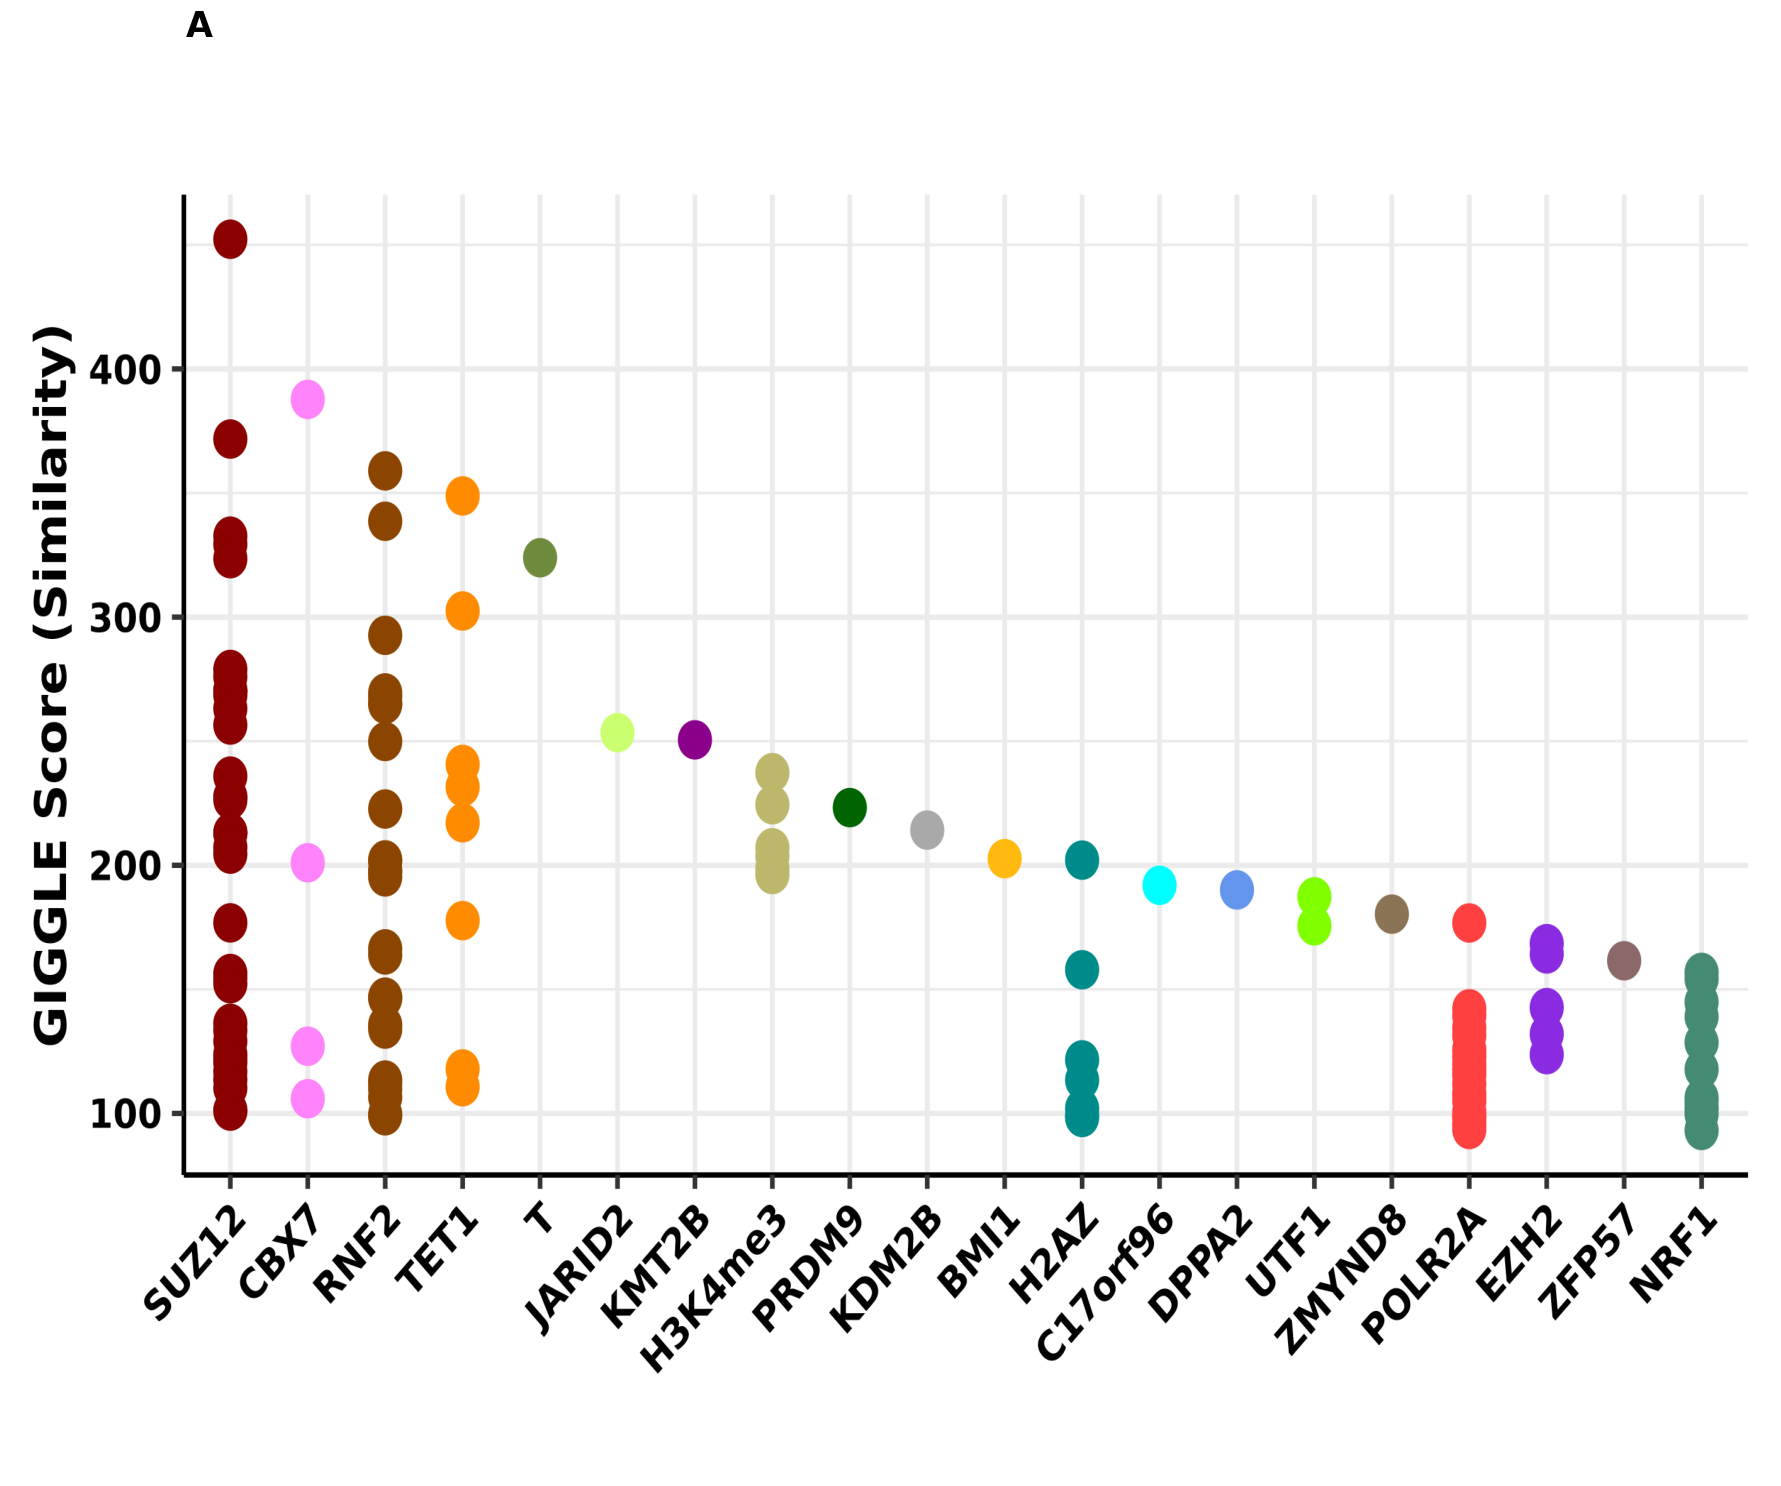

In [31]:
get_cistrome(probe_df, fig_w=5000, fig_h=1700, check_pval=False, top_10k=True)